## Add available landcover information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
MONTH = 'June'
PERIOD = '2nd'

In [5]:
#landcover data go up to 2021, update file when available

In [6]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-{MONTH}-{PERIOD}.csv', encoding=enc)
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()


In [7]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2023-06-16,θεσσαλιας,αγιας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,661.8,10705.0,17.3,45.76610,0.579373,0.228631,-0.496583,-0.228631,0.505902,0.222973,-0.435190,-0.222973,0.045626,0.030729,0.043382,0.030729,18.985714,23.864286,14.107143,10.014591,3.062158,9.497627,2.252233,16.518764,4.850248,17.420808,6.992874,25.793297,30.817772,182.906917,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,53,0,0
1,22.69237,39.13639,2023-06-16,θεσσαλιας,αλμυρου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,905.4,16004.0,20.6,45.23937,0.524939,0.255300,-0.438659,-0.255300,0.418770,0.174774,-0.364559,-0.174774,0.038430,0.031624,0.026601,0.031624,22.748889,31.152222,14.345556,11.574271,4.271414,11.566611,3.165456,16.910796,6.859971,19.659042,8.292132,47.173968,48.045618,293.275314,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,41,0,0
2,24.07379,39.32896,2023-06-16,θεσσαλιας,αλοννησου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,129.6,3153.0,21.2,46.11198,0.295426,-0.110578,-0.324886,0.110578,0.315954,-0.093238,-0.328222,0.093238,0.056677,0.050883,0.039039,0.050883,20.140000,21.990000,18.290000,12.912222,9.263333,11.806000,8.335714,15.332667,9.731333,17.710000,11.163333,0.000000,0.424733,203.495482,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,1,0,0
3,21.43051,39.22138,2023-06-16,θεσσαλιας,αργιθεας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,372.9,3515.0,9.3,44.69433,0.372873,0.219052,-0.319555,-0.219052,0.431552,0.282464,-0.338319,-0.282464,0.044504,0.029109,0.030439,0.029109,16.940000,22.356667,11.523333,6.545931,2.202813,6.295806,-1.524472,12.140821,3.852222,13.211548,4.210667,1.368029,2.328301,184.566360,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,50,0,0
4,22.88380,39.35198,2023-06-16,θεσσαλιας,βολου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,385.6,138865.0,374.6,45.52194,0.414137,0.091635,-0.375141,-0.091635,0.407453,0.094370,-0.370173,-0.094370,0.026706,0.028096,0.022356,0.028096,23.956667,33.116667,14.796667,13.062496,4.339126,13.258730,3.548556,18.642628,6.426410,21.021667,8.192857,10.707751,13.929444,189.756830,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,32,0,0


In [8]:
landcover.head()

,x,y,2001_01_01_lc_prop1,2001_01_01_lc_prop1_assessment,2001_01_01_lc_prop2,2001_01_01_lc_prop2_assessment,2001_01_01_lc_prop3,2001_01_01_lc_prop3_assessment,2001_01_01_lc_type1,2001_01_01_lc_type2,2001_01_01_lc_type3,2001_01_01_lc_type4,2001_01_01_lc_type5,2001_01_01_lw,2001_01_01_qc,2002_01_01_lc_prop1,2002_01_01_lc_prop1_assessment,2002_01_01_lc_prop2,2002_01_01_lc_prop2_assessment,2002_01_01_lc_prop3,2002_01_01_lc_prop3_assessment,2002_01_01_lc_type1,2002_01_01_lc_type2,2002_01_01_lc_type3,2002_01_01_lc_type4,2002_01_01_lc_type5,2002_01_01_lw,2002_01_01_qc,2003_01_01_lc_prop1,2003_01_01_lc_prop1_assessment,2003_01_01_lc_prop2,2003_01_01_lc_prop2_assessment,2003_01_01_lc_prop3,2003_01_01_lc_prop3_assessment,2003_01_01_lc_type1,2003_01_01_lc_type2,2003_01_01_lc_type3,2003_01_01_lc_type4,2003_01_01_lc_type5,2003_01_01_lw,2003_01_01_qc,2004_01_01_lc_prop1,2004_01_01_lc_prop1_assessment,2004_01_01_lc_prop2,2004_01_01_lc_prop2_assessment,2004_01_01_lc_prop3,2004_01_01_lc_prop3_assessment,2004_01_01_lc_type1,2004_01_01_lc_type2,2004_01_01_lc_type3,2004_01_01_lc_type4,2004_01_01_lc_type5,2004_01_01_lw,2004_01_01_qc,2005_01_01_lc_prop1,2005_01_01_lc_prop1_assessment,2005_01_01_lc_prop2,2005_01_01_lc_prop2_assessment,2005_01_01_lc_prop3,2005_01_01_lc_prop3_assessment,2005_01_01_lc_type1,2005_01_01_lc_type2,2005_01_01_lc_type3,2005_01_01_lc_type4,2005_01_01_lc_type5,2005_01_01_lw,2005_01_01_qc,2006_01_01_lc_prop1,2006_01_01_lc_prop1_assessment,2006_01_01_lc_prop2,2006_01_01_lc_prop2_assessment,2006_01_01_lc_prop3,2006_01_01_lc_prop3_assessment,2006_01_01_lc_type1,2006_01_01_lc_type2,2006_01_01_lc_type3,2006_01_01_lc_type4,2006_01_01_lc_type5,2006_01_01_lw,2006_01_01_qc,2007_01_01_lc_prop1,2007_01_01_lc_prop1_assessment,2007_01_01_lc_prop2,2007_01_01_lc_prop2_assessment,2007_01_01_lc_prop3,2007_01_01_lc_prop3_assessment,2007_01_01_lc_type1,2007_01_01_lc_type2,2007_01_01_lc_type3,2007_01_01_lc_type4,2007_01_01_lc_type5,2007_01_01_lw,2007_01_01_qc,2008_01_01_lc_prop1,2008_01_01_lc_prop1_assessment,2008_01_01_lc_prop2,2008_01_01_lc_prop2_assessment,2008_01_01_lc_prop3,2008_01_01_lc_prop3_assessment,2008_01_01_lc_type1,2008_01_01_lc_type2,2008_01_01_lc_type3,2008_01_01_lc_type4,2008_01_01_lc_type5,2008_01_01_lw,2008_01_01_qc,2009_01_01_lc_prop1,2009_01_01_lc_prop1_assessment,2009_01_01_lc_prop2,2009_01_01_lc_prop2_assessment,2009_01_01_lc_prop3,2009_01_01_lc_prop3_assessment,2009_01_01_lc_type1,2009_01_01_lc_type2,2009_01_01_lc_type3,2009_01_01_lc_type4,2009_01_01_lc_type5,2009_01_01_lw,2009_01_01_qc,2010_01_01_lc_prop1,2010_01_01_lc_prop1_assessment,2010_01_01_lc_prop2,2010_01_01_lc_prop2_assessment,2010_01_01_lc_prop3,2010_01_01_lc_prop3_assessment,2010_01_01_lc_type1,2010_01_01_lc_type2,2010_01_01_lc_type3,2010_01_01_lc_type4,2010_01_01_lc_type5,2010_01_01_lw,2010_01_01_qc,2011_01_01_lc_prop1,2011_01_01_lc_prop1_assessment,2011_01_01_lc_prop2,2011_01_01_lc_prop2_assessment,2011_01_01_lc_prop3,2011_01_01_lc_prop3_assessment,2011_01_01_lc_type1,2011_01_01_lc_type2,2011_01_01_lc_type3,2011_01_01_lc_type4,2011_01_01_lc_type5,2011_01_01_lw,2011_01_01_qc,2012_01_01_lc_prop1,2012_01_01_lc_prop1_assessment,2012_01_01_lc_prop2,2012_01_01_lc_prop2_assessment,2012_01_01_lc_prop3,2012_01_01_lc_prop3_assessment,2012_01_01_lc_type1,2012_01_01_lc_type2,2012_01_01_lc_type3,2012_01_01_lc_type4,2012_01_01_lc_type5,2012_01_01_lw,2012_01_01_qc,2013_01_01_lc_prop1,2013_01_01_lc_prop1_assessment,2013_01_01_lc_prop2,2013_01_01_lc_prop2_assessment,2013_01_01_lc_prop3,2013_01_01_lc_prop3_assessment,2013_01_01_lc_type1,2013_01_01_lc_type2,2013_01_01_lc_type3,2013_01_01_lc_type4,2013_01_01_lc_type5,2013_01_01_lw,2013_01_01_qc,2014_01_01_lc_prop1,2014_01_01_lc_prop1_assessment,2014_01_01_lc_prop2,2014_01_01_lc_prop2_assessment,2014_01_01_lc_prop3,2014_01_01_lc_prop3_assessment,2014_01_01_lc_type1,2014_01_01_lc_type2,2014_01_01_lc_type3,2014_01_01_lc_type4,2014_01_01_lc_type5,2014_01_01_lw,2014_01_01_qc,2015_01_01_lc_prop1,2015_01_01_lc_prop1_assessment,2015_01_01

In [9]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [10]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))


In [11]:
data_years = dataset['year'].unique().tolist()

In [12]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [13]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.0
Max distance: 7.1851740491832965


In [14]:
dataset_final = pd.DataFrame()

In [15]:
for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

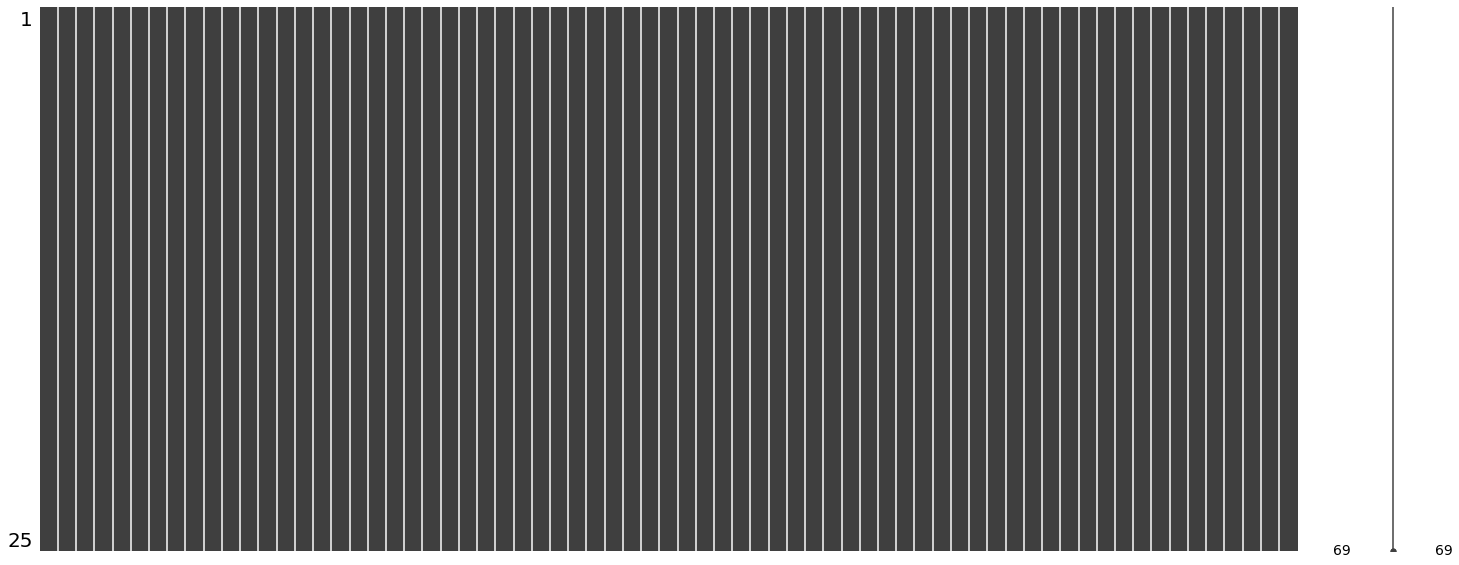

In [16]:
missingno.matrix(dataset_final)

In [17]:
cols = dataset_final.columns

In [18]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [19]:
len(cols)

69

In [20]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [21]:
len(rearranged)

69

In [22]:
dataset_final = dataset_final[rearranged]

In [23]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)